# [LAB-06] 10. Stacked Bar Plot

## #01. 준비작업

### 1. 패키지 참조

In [1]:
from jussam import load_data
from helpers import *
from pandas import pivot_table
import seaborn as sb
import numpy as np

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터셋 불러오기

In [2]:
origin = load_data("region_jobs")
origin

📚 지역별 산업 종사자 수를 조사한 가상의 데이터


,지역,산업,종사자 수
0,서울,서비스업,520
1,부산,서비스업,340
2,대구,서비스업,280
3,인천,서비스업,310
4,서울,제조업,180
5,부산,제조업,220
6,대구,제조업,160
7,인천,제조업,140
8,서울,IT산업,260
9,부산,IT산업,110


### 3. 데이터 전처리 

- 피벗 테이블 구성

In [3]:
# # 데이터 피벗팅 (fill_value=0 --> 결측치를 0으로 채움)
df = pivot_table(origin, index="지역", columns="산업", 
                 values="종사자 수", aggfunc=np.sum, fill_value=0)

# 인덱스를 문자열 카테고리로 변환
df.index = df.index.astype('str').astype('category')

df

/var/folders/yd/ms1f950j3h349tw8w7kx8g2m0000gn/T/ipykernel_46884/3582114666.py:2: FutureWarning: The provided callable <function sum at 0x11423c360> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = pivot_table(origin, index="지역", columns="산업",


산업,IT산업,서비스업,제조업
지역,,,
대구,90,280,160
부산,110,340,220
서울,260,520,180
인천,150,310,140


## #02. 절대값 누적 막대 그래프

### 1. step1 - 기본 막대 그래프 생성

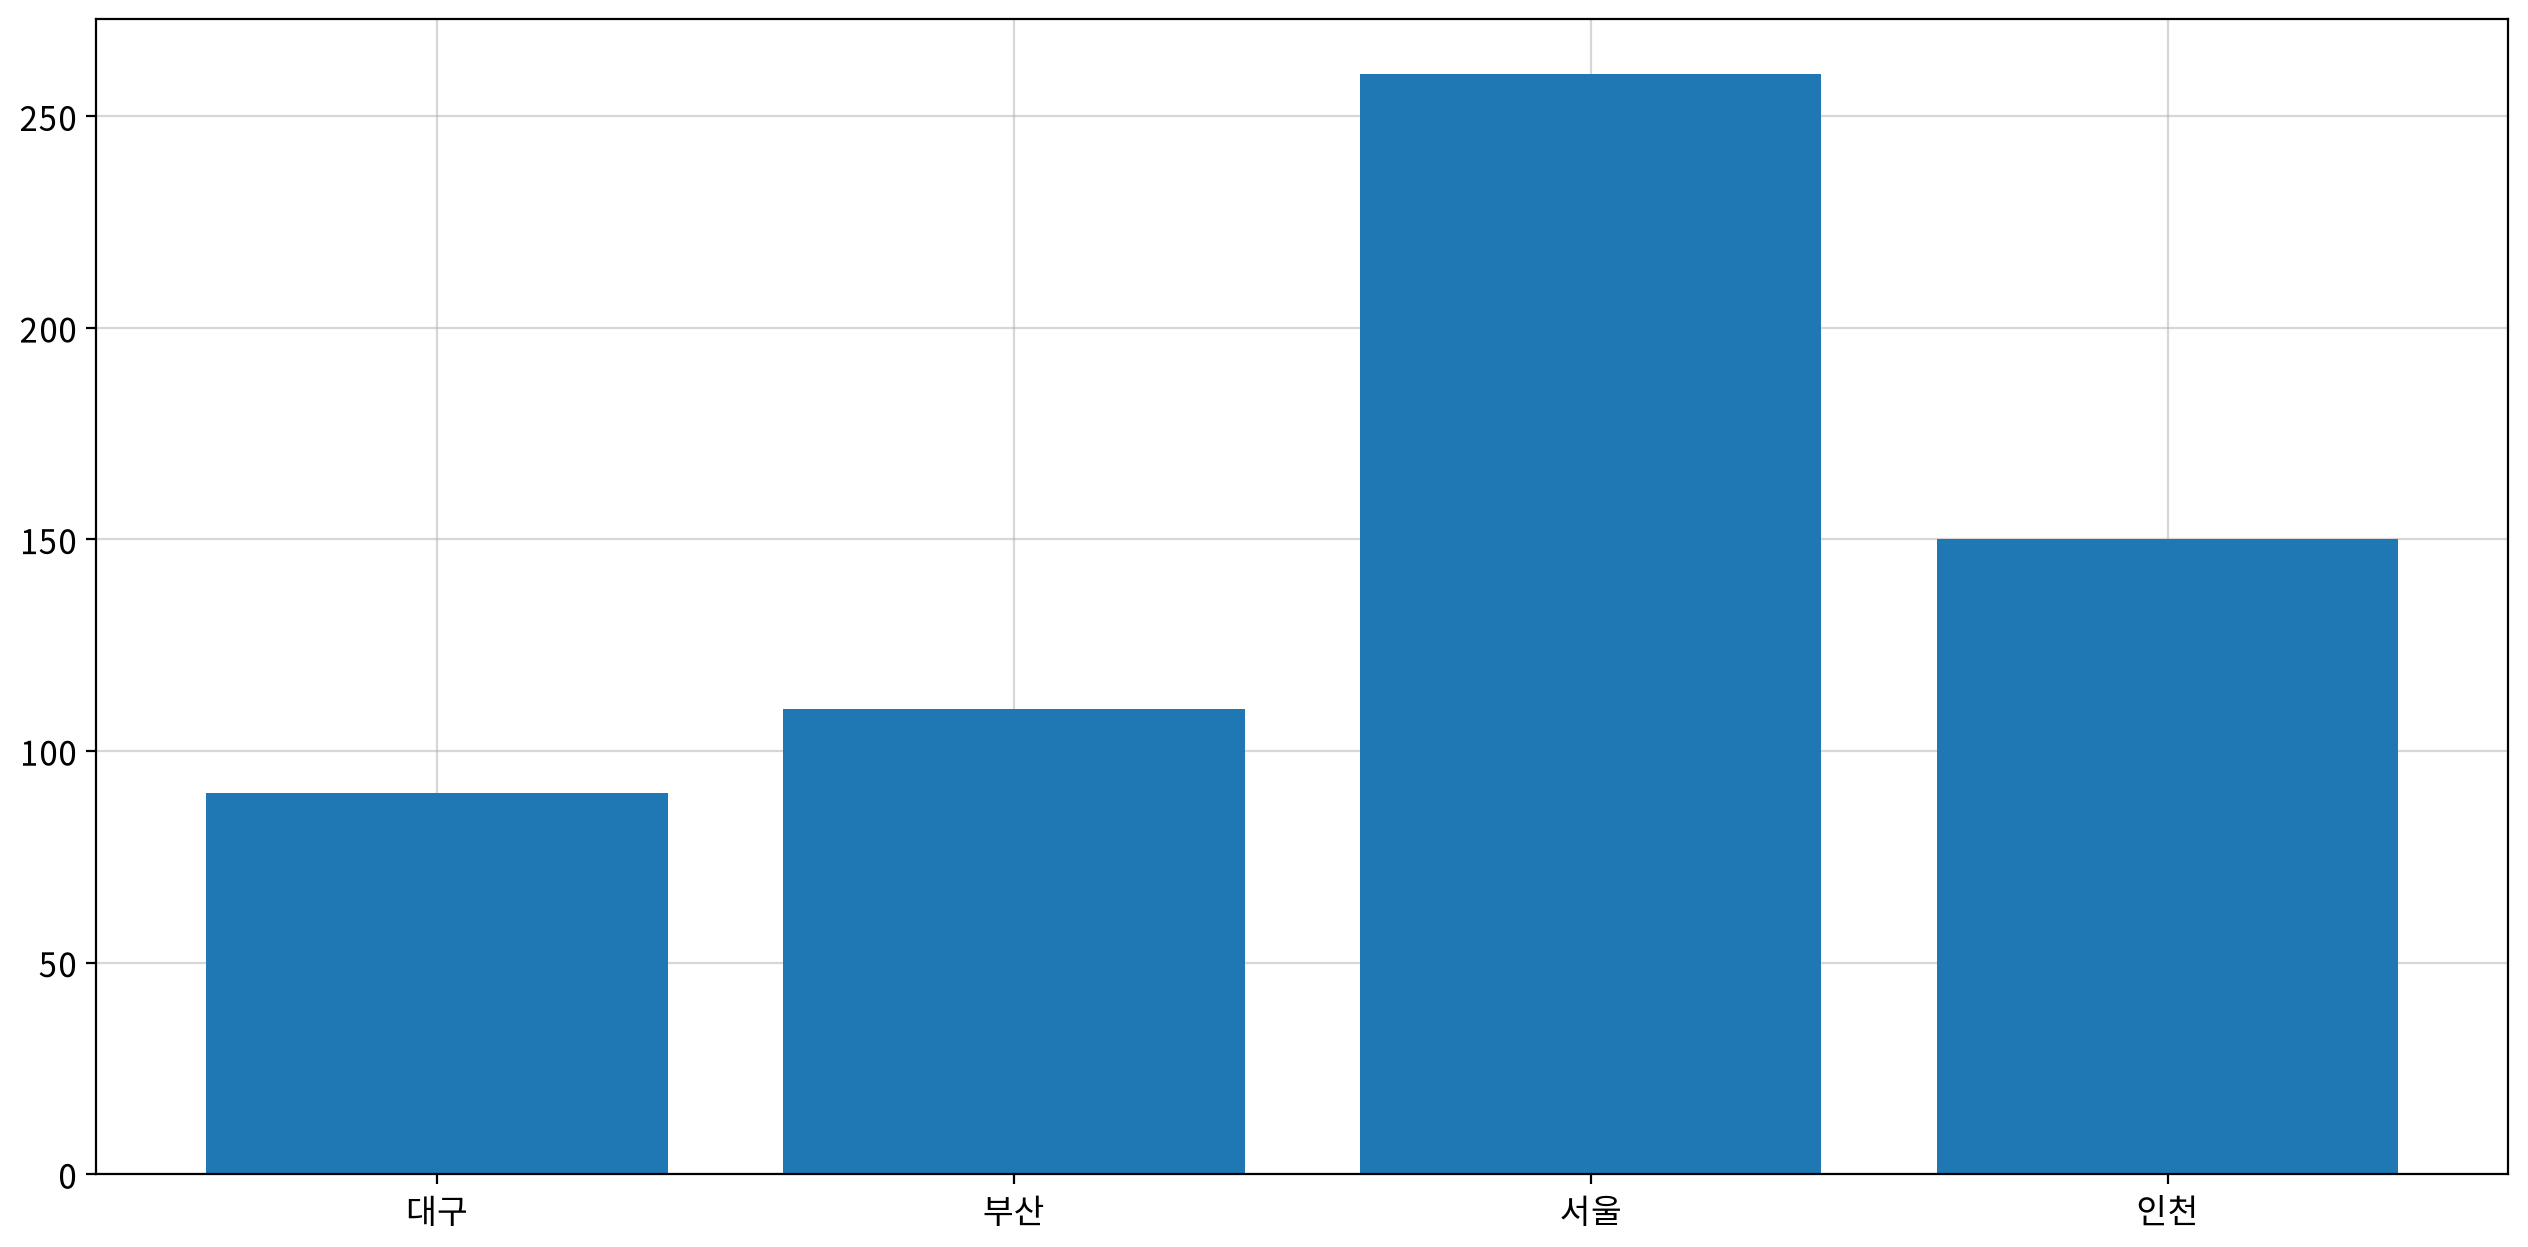

In [4]:
fig, ax = my_plot.init()

# 지역별 IT산업 종사자 수에 대한 기본 막대 그래프
ax.bar(df.index, df['IT산업'])

my_plot.show()

### 2. step2 - 막대 그래프 위에 새로운 데이터 쌓기

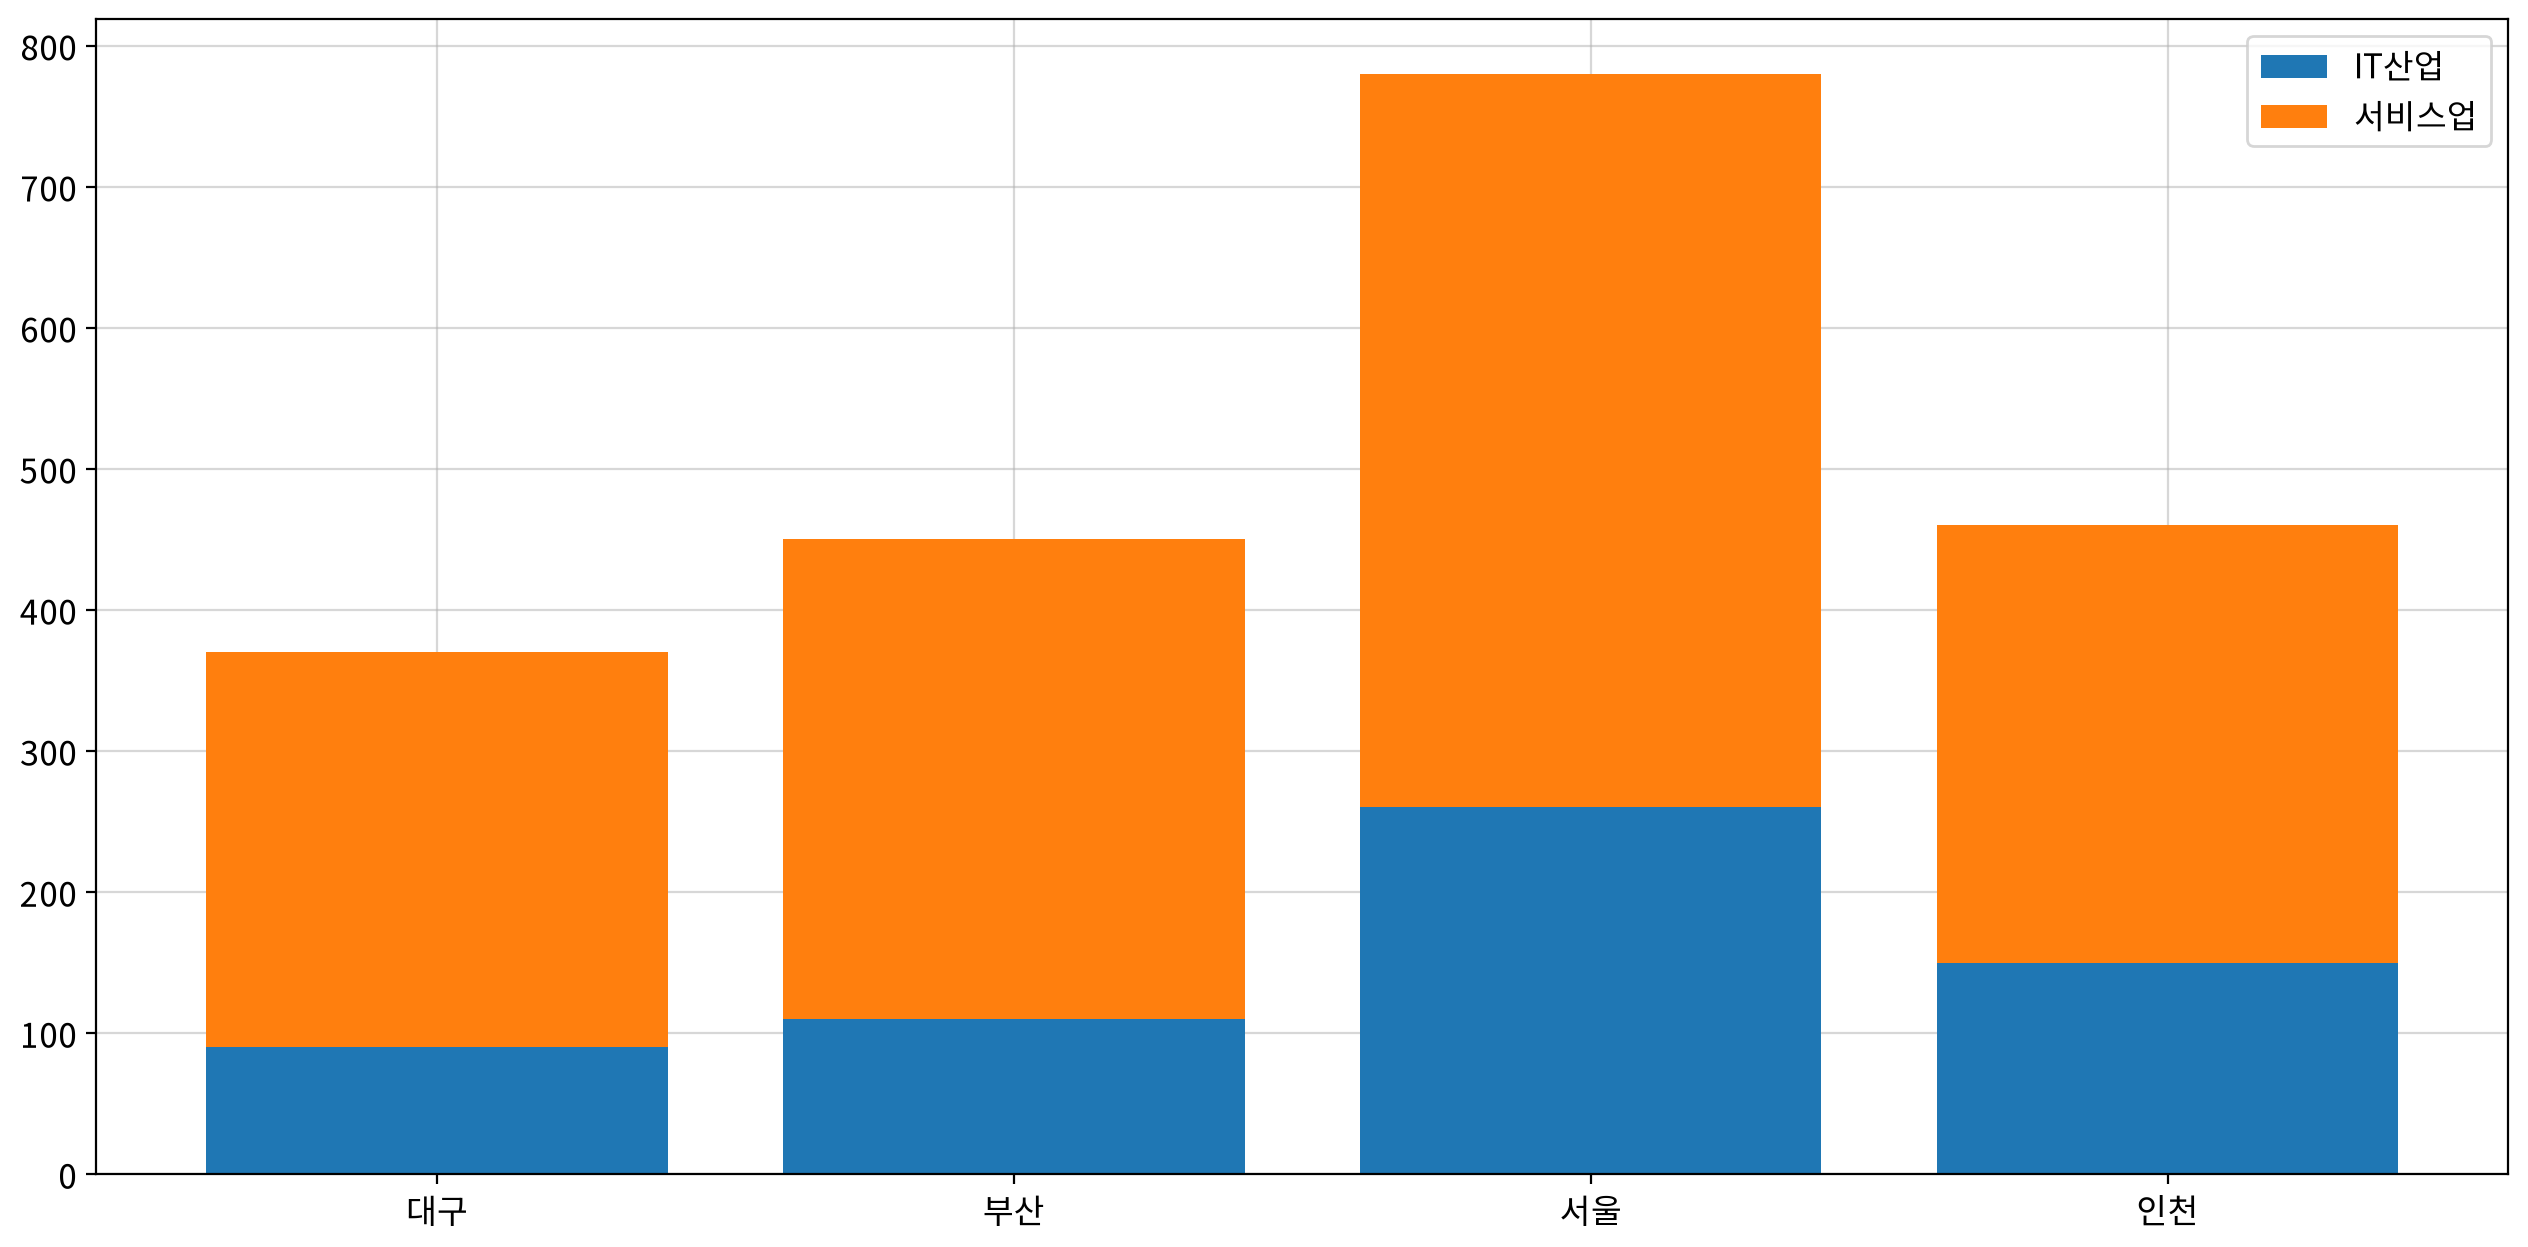

In [5]:
fig, ax = my_plot.init()

# 지역별 IT산업 종사자 수에 대한 기본 막대 그래프
ax.bar(df.index, df['IT산업'], label='IT산업')

# 기본 막대 그래프 위에 지역별 서비스업 종사자 수를 누적하여 표시
ax.bar(df.index, df['서비스업'], bottom=df['IT산업'], label='서비스업')

# 기본 막대 그래프와 누적 막대 그래프에 대한 범례 추가
# -> bbox_to_anchor=(1, 1) : 범주의 위치 오른쪽(1) 상단(1)
# -> bbox_to_anchor=(0, 0) : 범주 위치 왼쪽(0) 하단(0)
ax.legend(bbox_to_anchor=(1, 1))

my_plot.show()

### 3. step3 - 추가 데이터 쌓기

- 필요한 만큼 데이터를 누적하여 쌓을 수 있다.

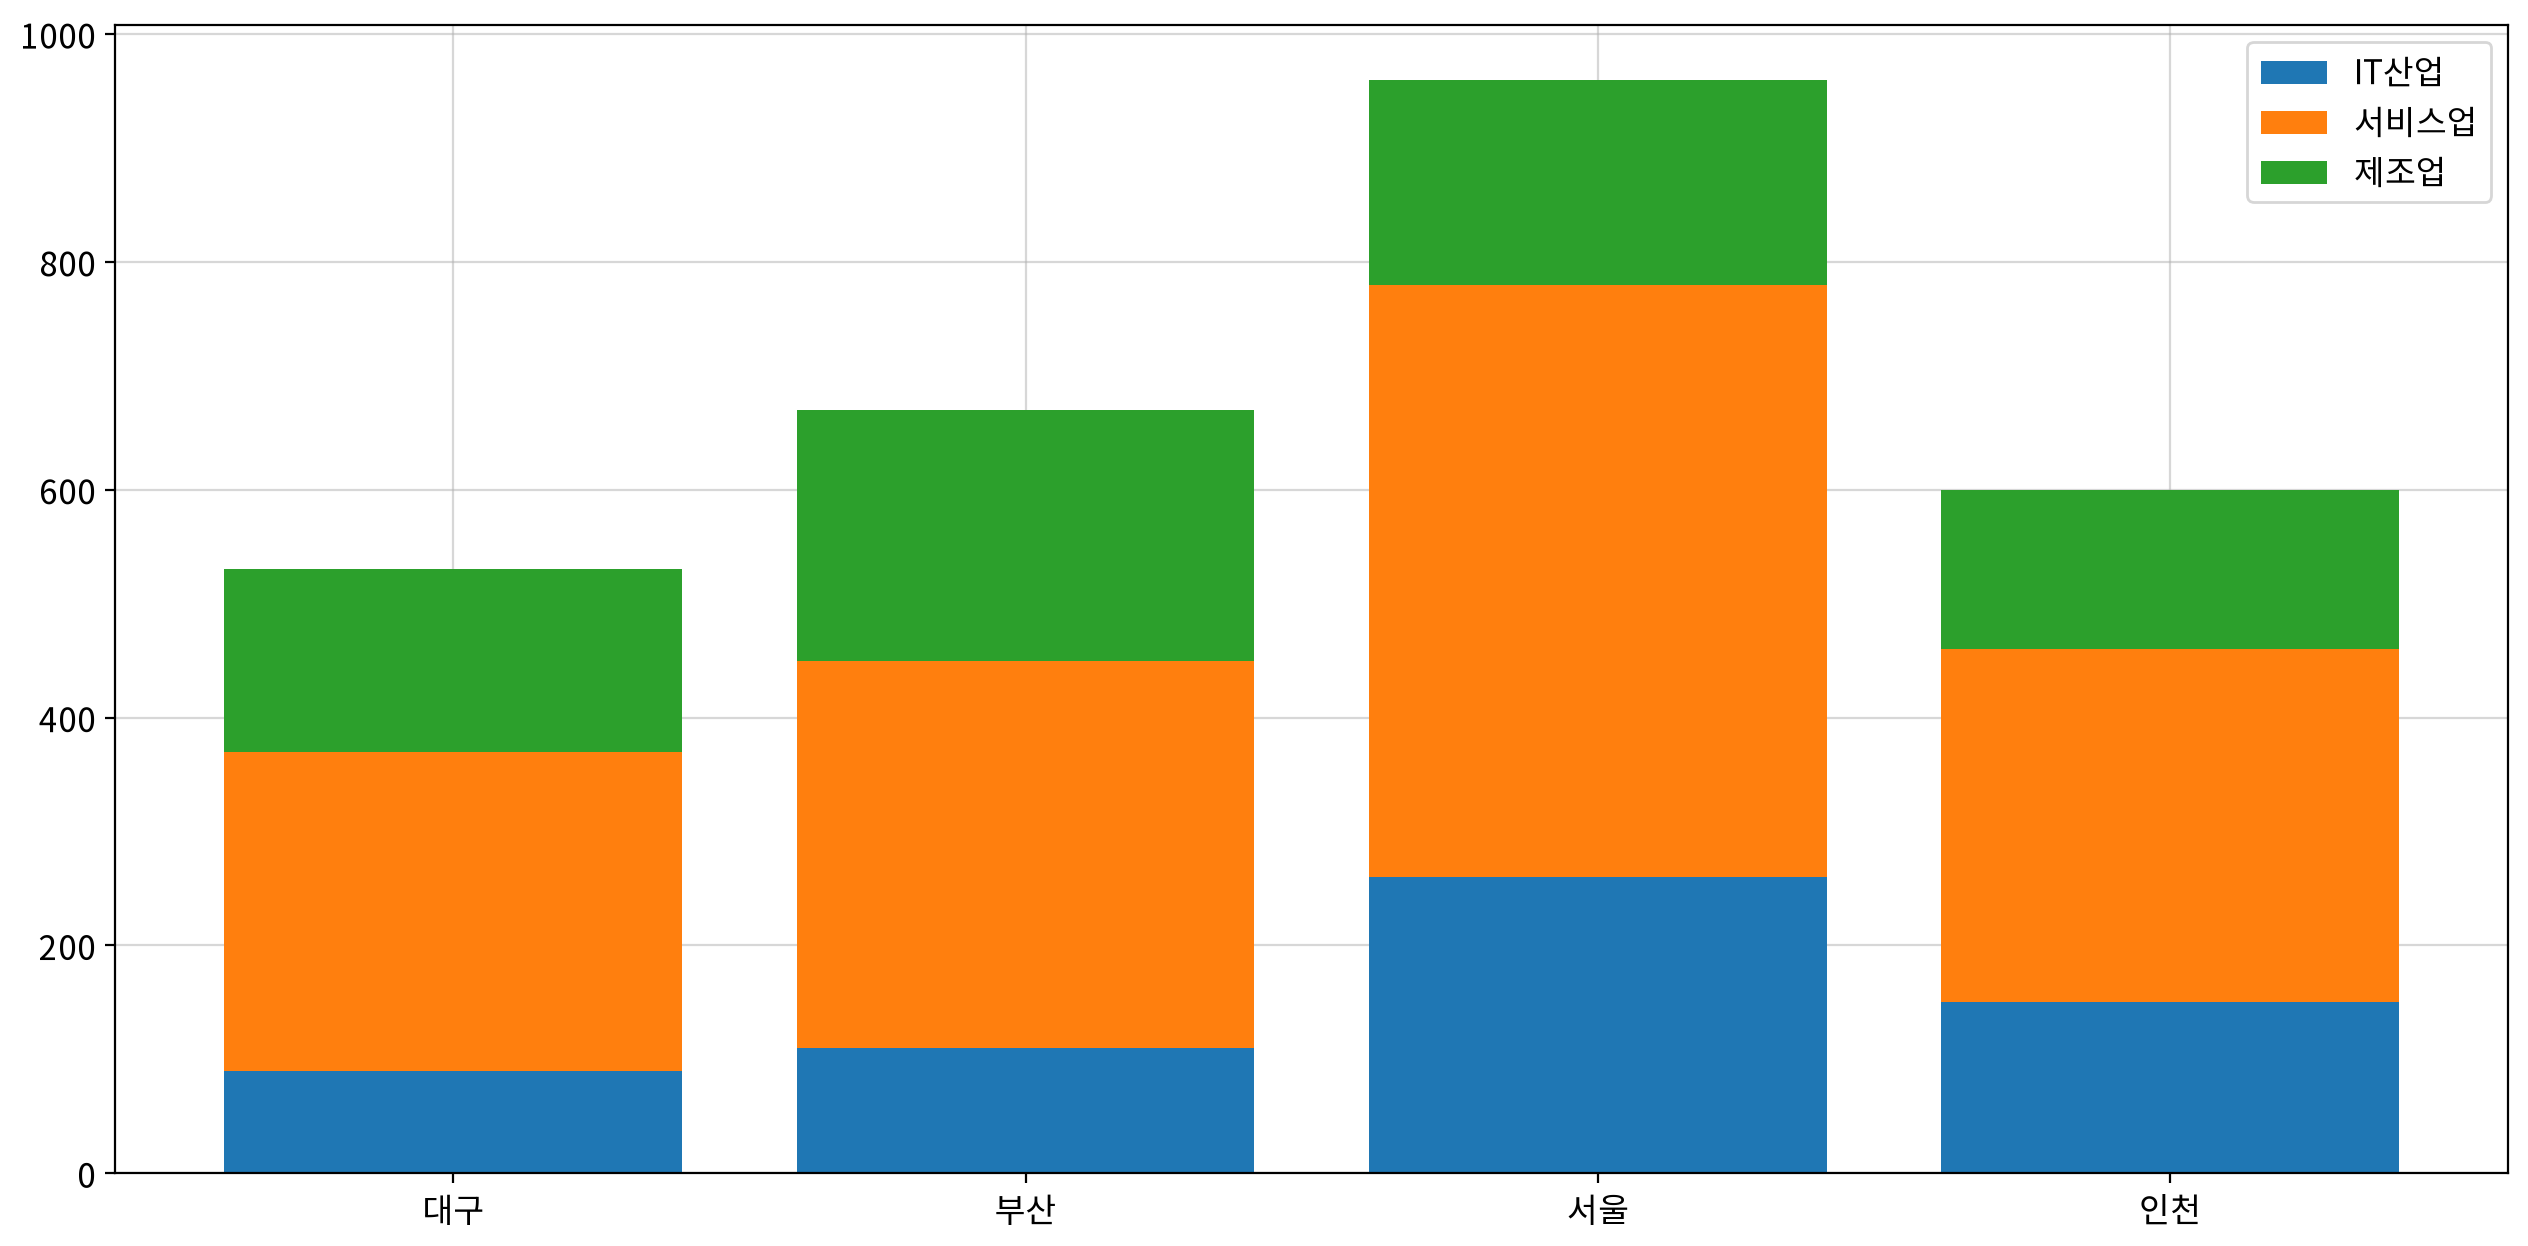

In [6]:
fig, ax = my_plot.init()

# 지역별 IT산업 종사자 수에 대한 기본 막대 그래프
ax.bar(df.index, df['IT산업'], label='IT산업')

# 기본 막대 그래프 위에 지역별 서비스업 종사자 수를 누적하여 표시
ax.bar(df.index, df['서비스업'], bottom=df['IT산업'], label='서비스업')

# 서비스업과 IT산업 위에 지역별 제조업 종사자 수를 누적하여 표시
ax.bar(df.index, df['제조업'], bottom=df['IT산업'] + df['서비스업'], label='제조업')

# 기본 막대 그래프, 서비스업 누적 막대 그래프, 제조업 누적 막대 그래프에 대한 범례 추가
ax.legend(bbox_to_anchor=(1, 1))

my_plot.show()

### 4. step4 - 각 영역 안에 수치값 표시하기

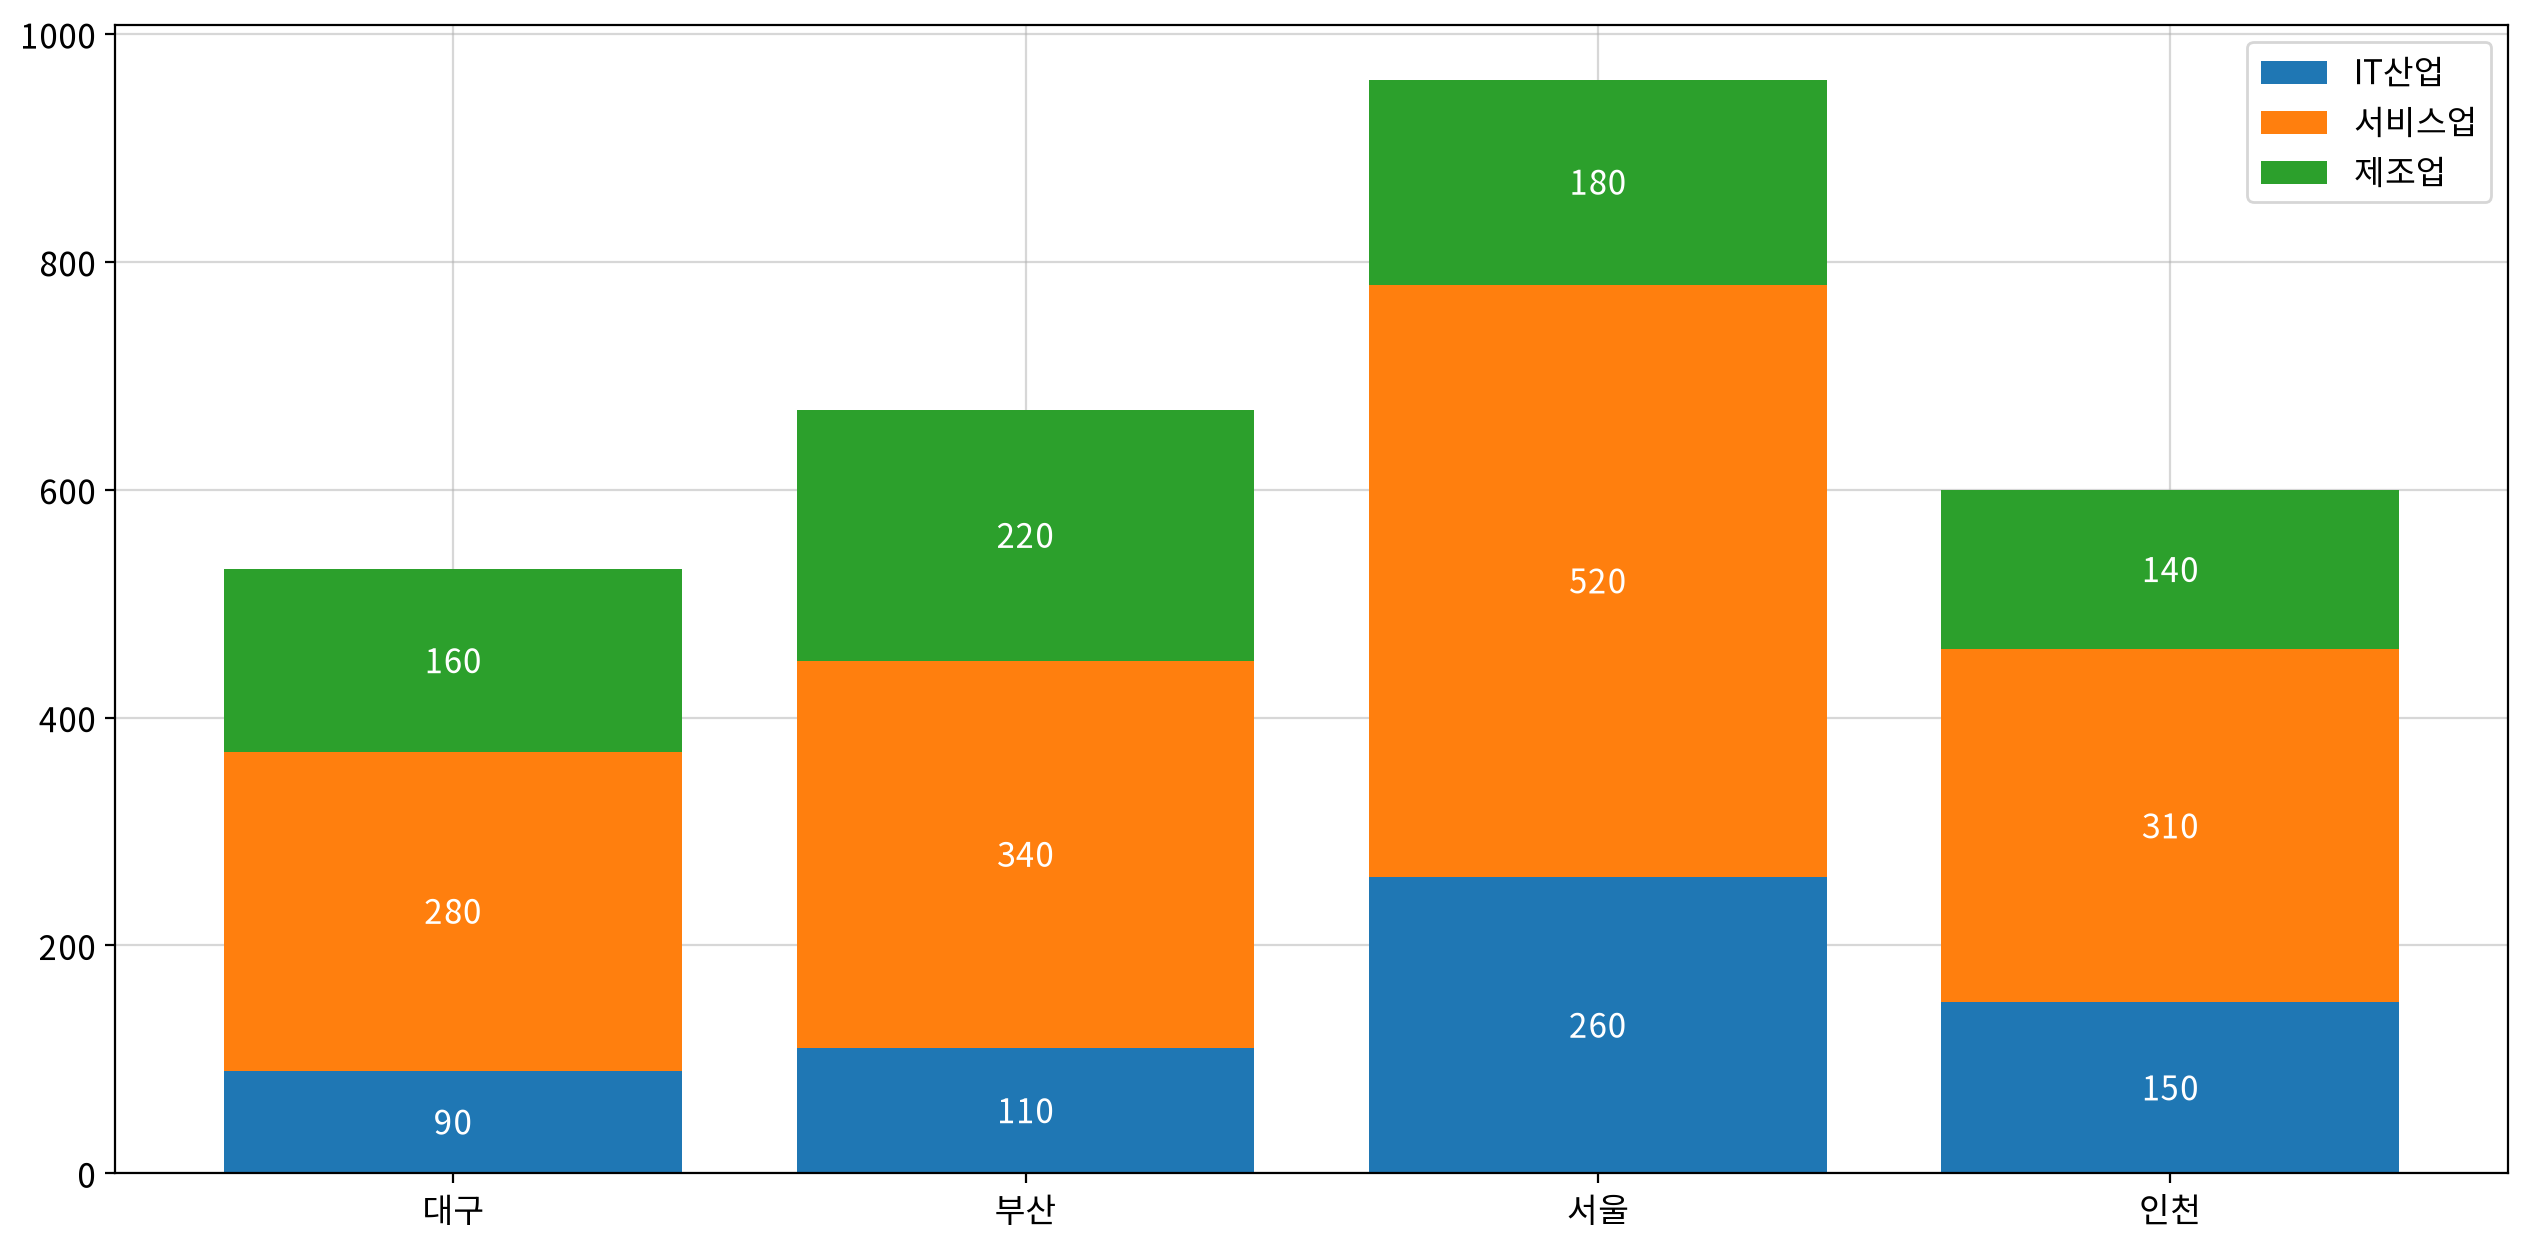

In [7]:
fig, ax = my_plot.init()

# 지역별 IT산업 종사자 수에 대한 기본 막대 그래프
ax.bar(df.index, df['IT산업'], label='IT산업')

# 기본 막대 그래프 위에 지역별 서비스업 종사자 수를 누적하여 표시
ax.bar(df.index, df['서비스업'], bottom=df['IT산업'], label='서비스업')

# 서비스업과 IT산업 위에 지역별 제조업 종사자 수를 누적하여 표시
ax.bar(df.index, df['제조업'], bottom=df['IT산업'] + df['서비스업'], label='제조업')

# 기본 막대 그래프, 서비스업 누적 막대 그래프, 제조업 누적 막대 그래프에 대한 범례 추가
ax.legend(bbox_to_anchor=(1, 1))

# 각 막대 위에 종사자 수 표시
for i in df.index:
    ax.text(x=i, y=df['IT산업'][i] / 2, s=str(df['IT산업'][i]), 
            ha='center', va='center', color='white', fontsize=12)
    ax.text(x=i, y=df['IT산업'][i] + df['서비스업'][i] / 2, s=str(df['서비스업'][i]), 
            ha='center', va='center', color='white', fontsize=12)
    ax.text(x=i, y=df['IT산업'][i] + df['서비스업'][i] + df['제조업'][i] / 2, s=str(df['제조업'][i]), 
            ha='center', va='center', color='white', fontsize=12)

my_plot.show()

## #03. 색상 팔레트 적용하기

### 1. seaborn의 팔레트에서 범주의 종류 수 만큼 색상 추출

In [8]:
# seaborn의 pastel color palette 사용
colors = sb.color_palette("Set2", 3)
colors

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549)]

### 2. 색상을 적용한 가로 누적 막대 그래프

- barh 함수를 사용한다.
  - `bottom`이 아닌 `left`를 사용한다.
  - 색상을 적용한다.
  - 텍스트 출력의 x좌표와 y좌표를 서로 바꿔서 지정한다.

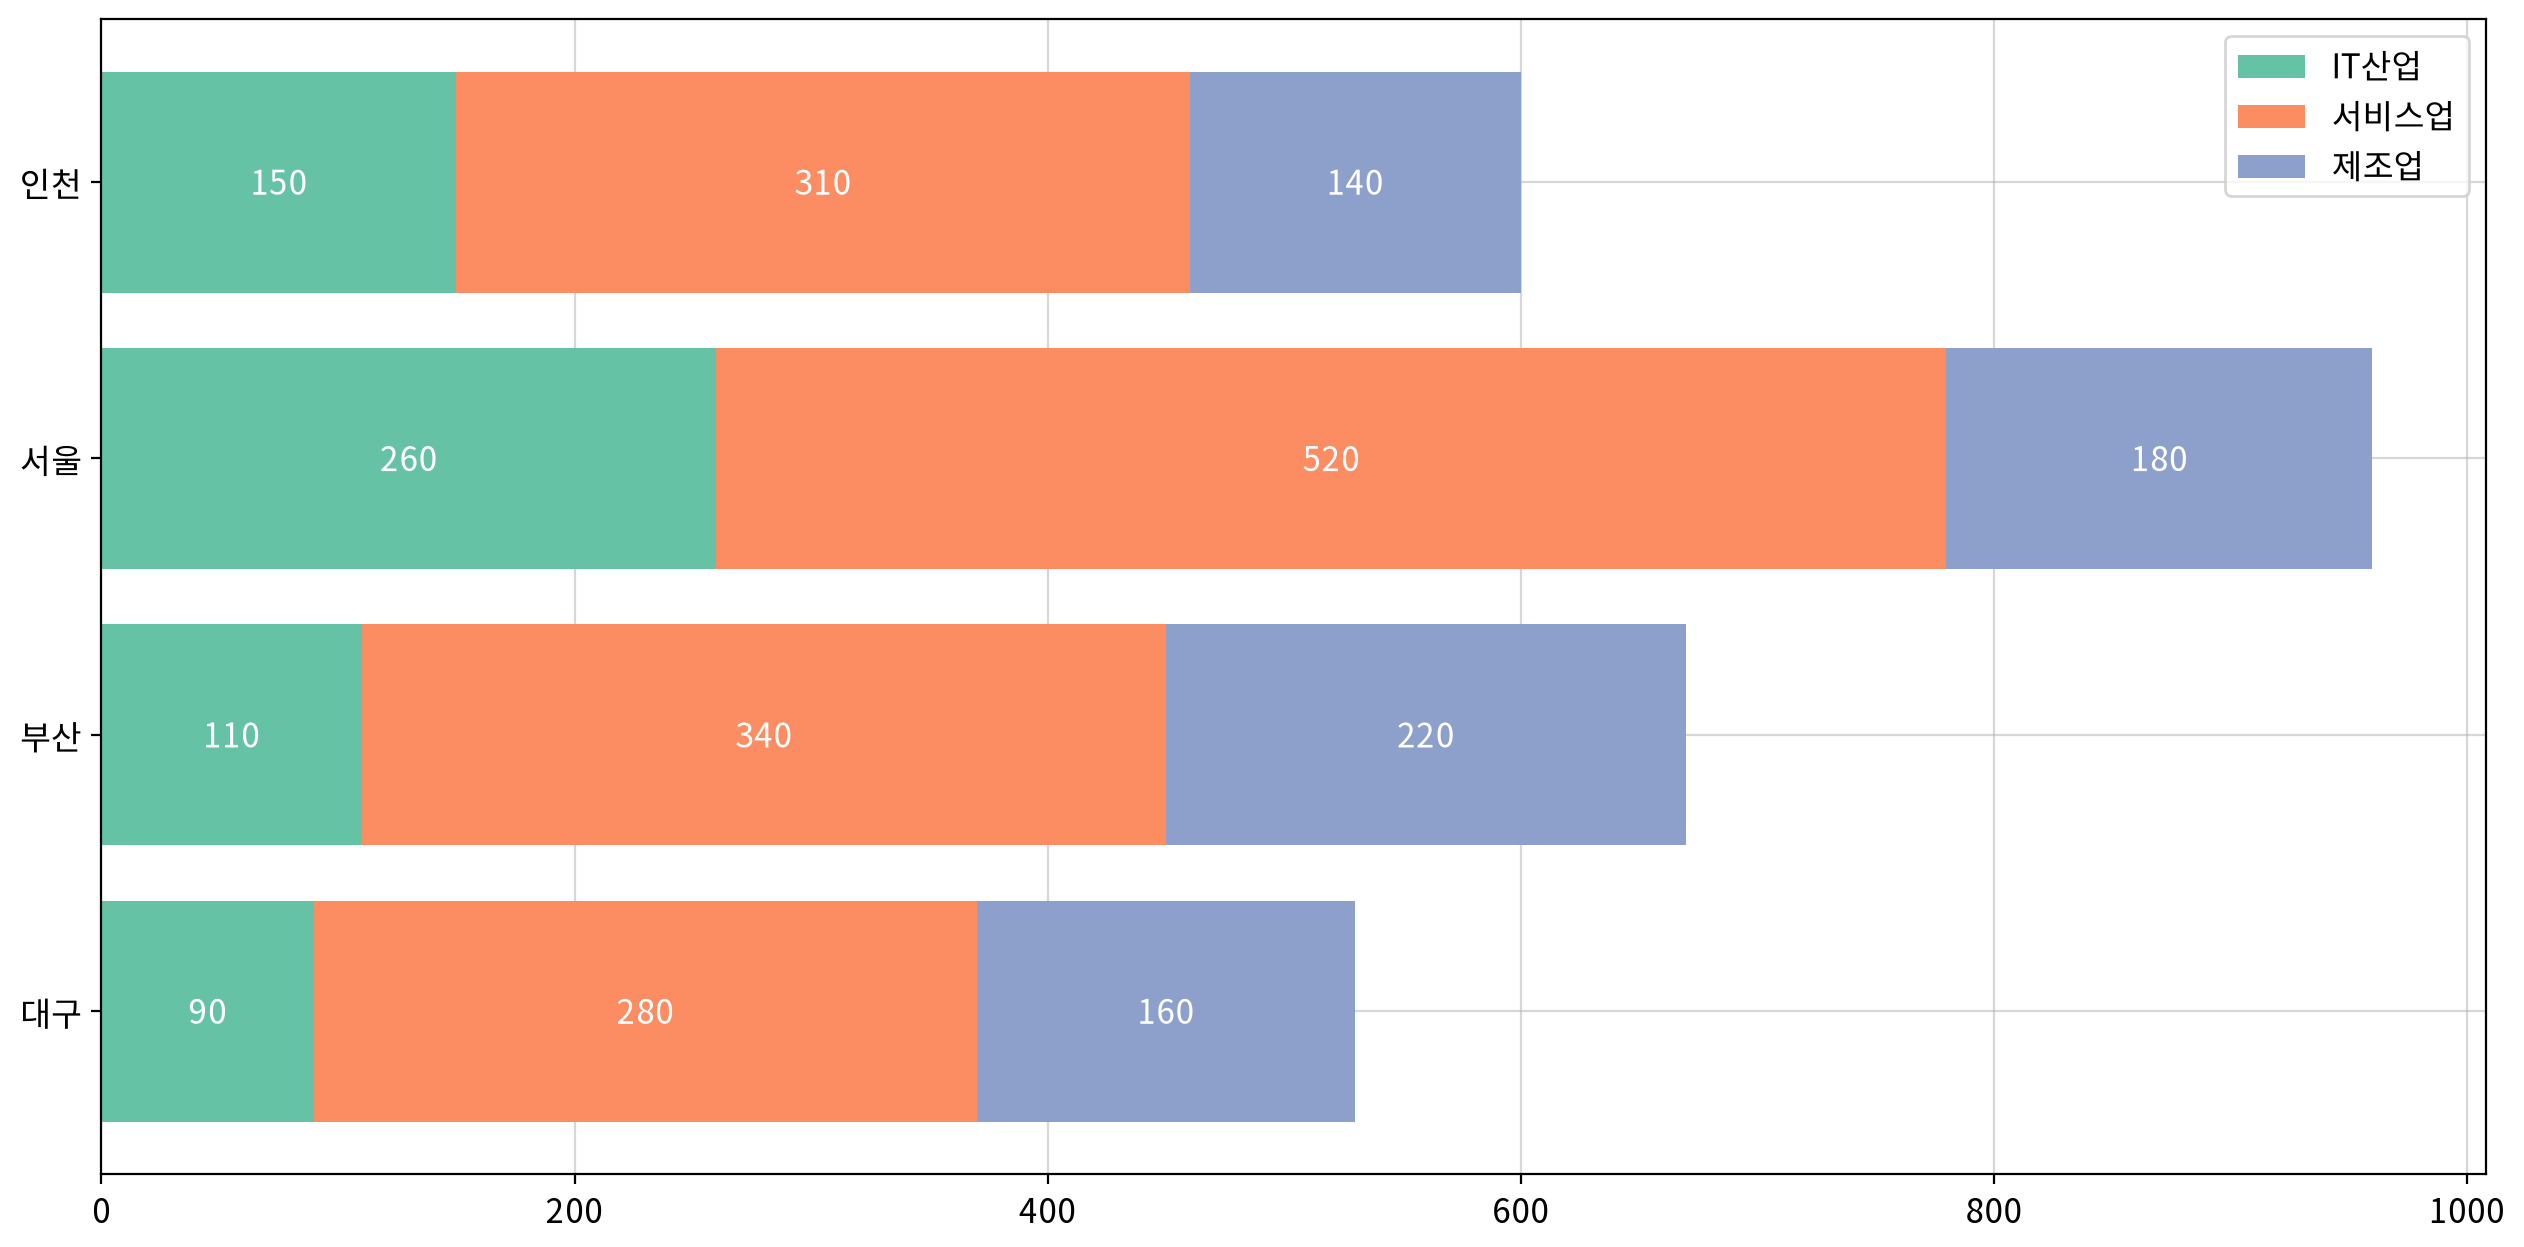

In [9]:
fig, ax = my_plot.init()

# 지역별 IT산업 종사자 수에 대한 기본 막대 그래프
ax.barh(df.index, df['IT산업'], label='IT산업', color=colors[0])

# 기본 막대 그래프 위에 지역별 서비스업 종사자 수를 누적하여 표시
ax.barh(df.index, df['서비스업'], left=df['IT산업'], label='서비스업', 
       color=colors[1])

# 서비스업과 IT산업 위에 지역별 제조업 종사자 수를 누적하여 표시
ax.barh(df.index, df['제조업'], left=df['IT산업'] + df['서비스업'], label='제조업', 
       color=colors[2])

# 기본 막대 그래프, 서비스업 누적 막대 그래프, 제조업 누적 막대 그래프에 대한 범례 추가
ax.legend(bbox_to_anchor=(1, 1))

# 각 막대 위에 종사자 수 표시
for i in df.index:
    ax.text(x=df['IT산업'][i] / 2, y=i, 
            s=str(df['IT산업'][i]), 
            ha='center', va='center', color='white', fontsize=12)
    ax.text(x=df['IT산업'][i] + df['서비스업'][i] / 2, y=i, 
            s=str(df['서비스업'][i]), 
            ha='center', va='center', color='white', fontsize=12)
    ax.text(x=df['IT산업'][i] + df['서비스업'][i] + df['제조업'][i] / 2, y=i, 
            s=str(df['제조업'][i]), 
            ha='center', va='center', color='white', fontsize=12)

my_plot.show()

## #04. 모듈화 기능 확인

/Users/leekh/hossam-ml/helpers/my_plot.py:589: FutureWarning: The provided callable <function sum at 0x11423c360> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = pivot_table(data=data, index=x, values=y, columns=hue, aggfunc=aggfunc, fill_value=0)


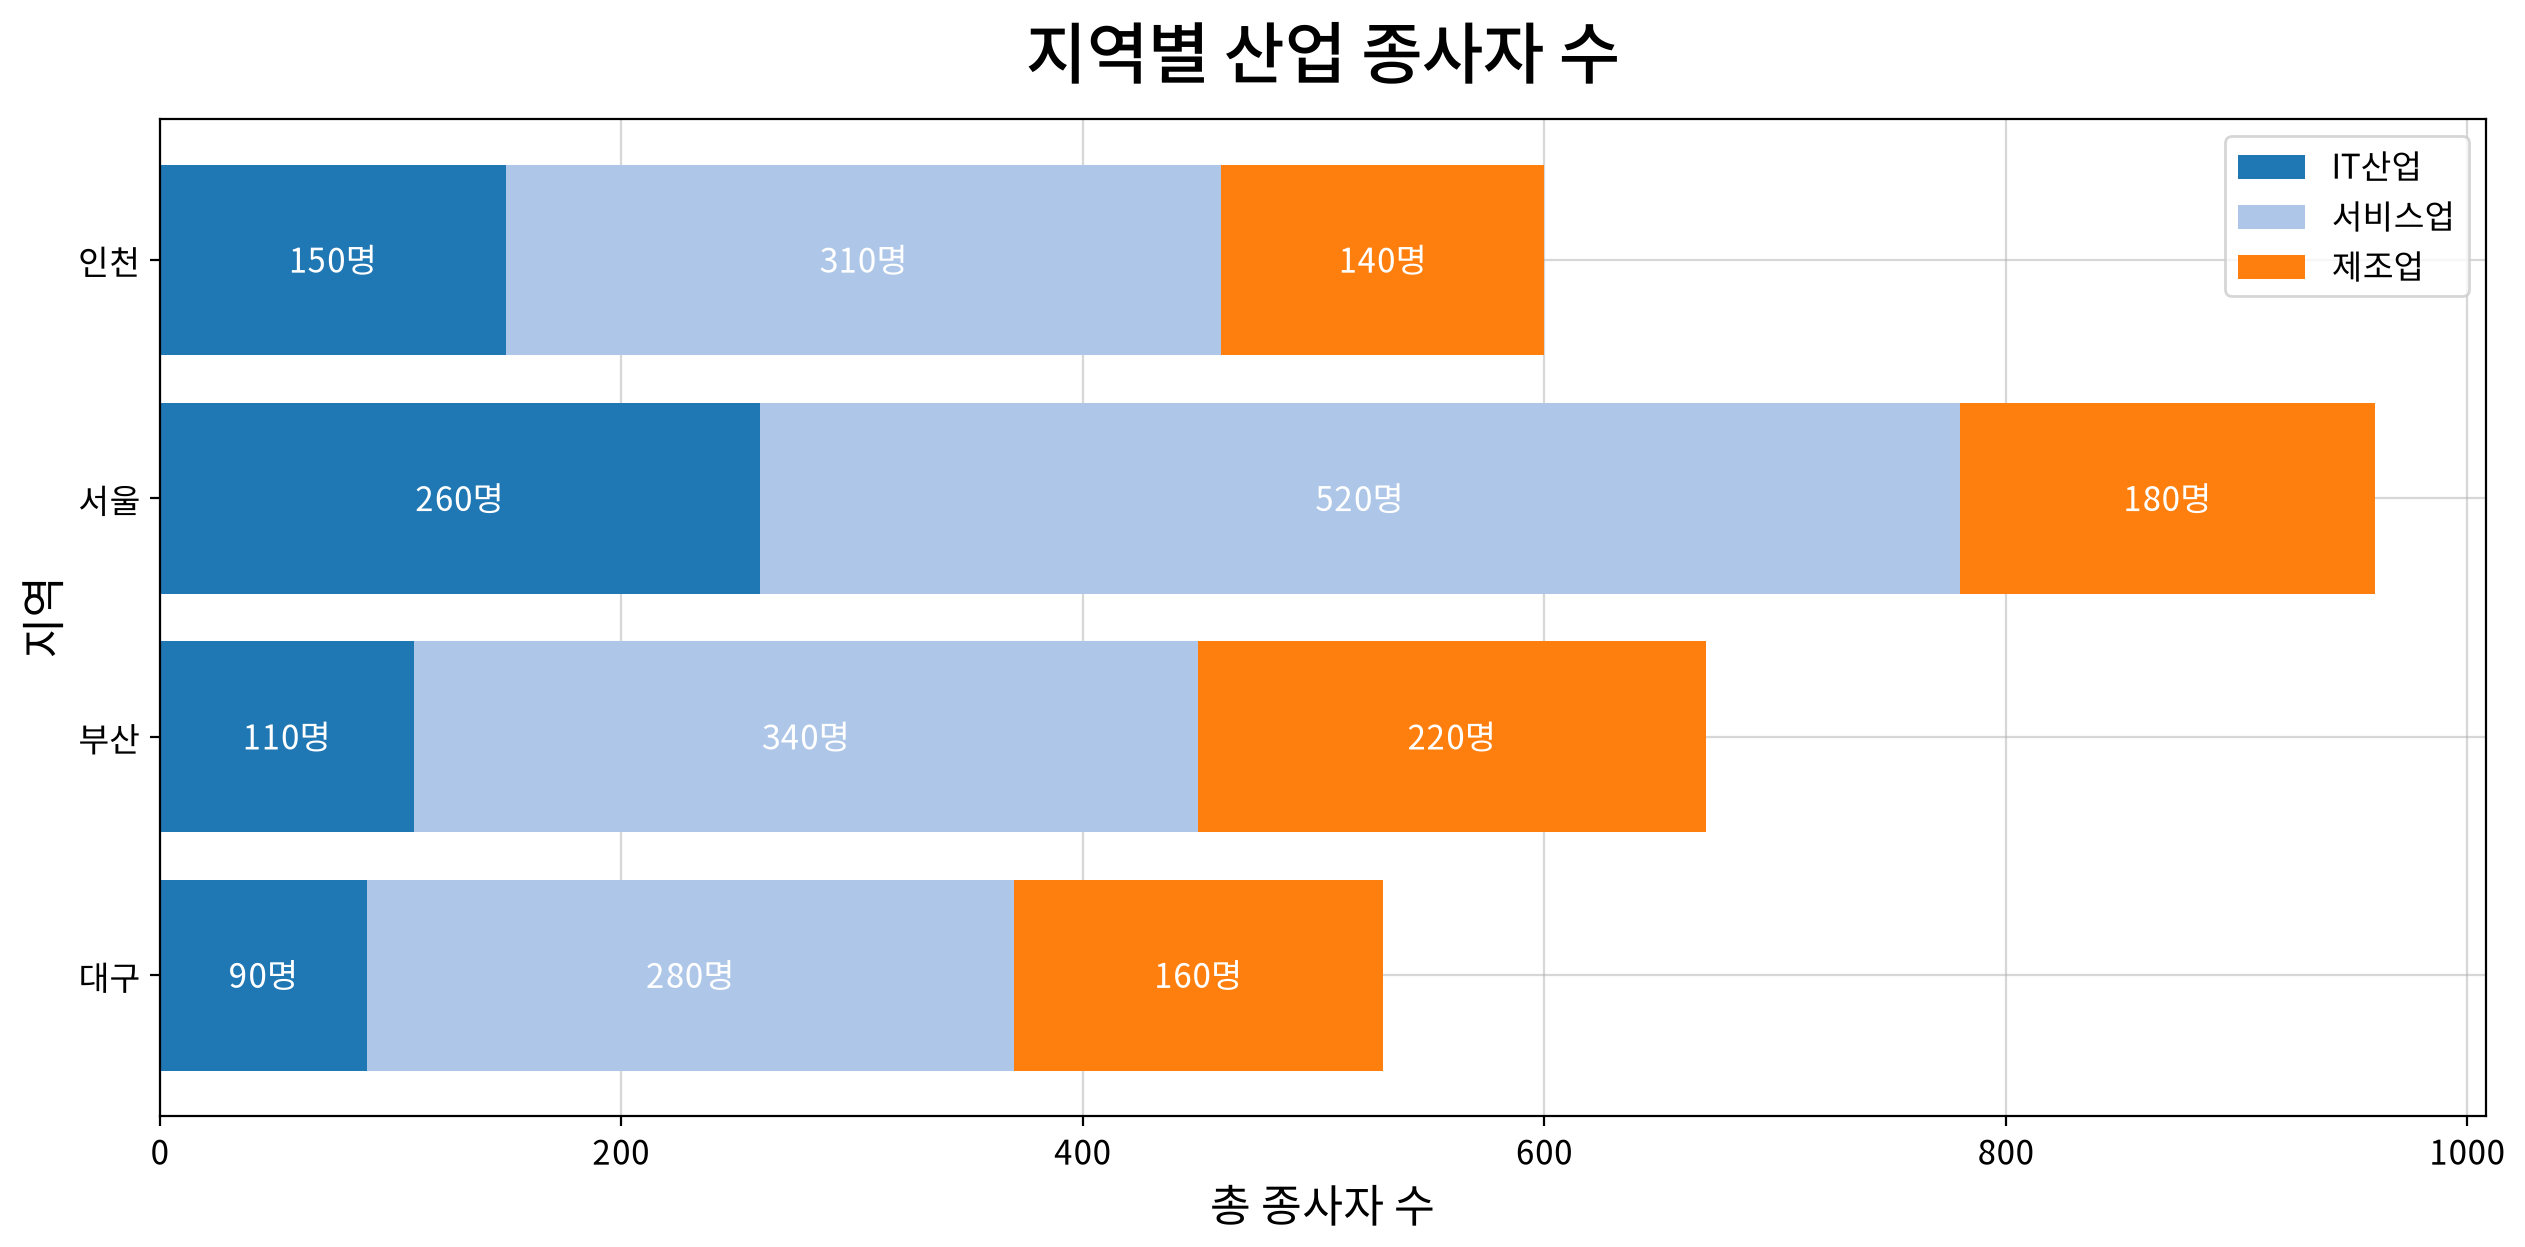

In [10]:
my_plot.stackplot(data=origin,              # 데이터프레임
                x="지역",                   # x축에 사용할 열 이름
                y="종사자 수",               # y축에 사용할 열 이름
                hue="산업",                 # 누적 막대그래프의 범주형 열 이름
                aggfunc=np.sum,             # 집계 함수 (기본값: np.sum) 
                orient='h',                 # 그래프 방향 ('v' -> 수직, 'h' -> 수평)
                text_format="{:d}명",       # 텍스트 포멧 (기본값: "{:.1f}")
                palette="tab20",            # 색상 팔레트 (기본값: None)
                title="지역별 산업 종사자 수", # 그래프 제목 (기본값: None)
                xlabel="총 종사자 수",       # x축 레이블 (기본값: None)
                ylabel="지역")              # y축 레이블 (기본값: None)

#### 💡 인사이트

- 📍 지역별 총 종사자 수는 서울 960명, 부산 670명, 인천 600명, 대구 530명 순임.
- 🥇 모든 지역에서 서비스업 종사자 수가 가장 큼.
- 🏙️ 서울은 IT산업 260명, 서비스업 520명, 제조업 180명으로 세 산업 모두에서 가장 큰 값을 보임.
- 🏭 제조업 종사자 수는 부산 220명으로 가장 크고, 서울 180명, 대구 160명, 인천 140명 순임.
- 💻 IT산업 종사자 수는 서울 260명으로 가장 크고, 인천 150명, 부산 110명, 대구 90명 순임.
- ➕ 서비스업과 제조업 합계는 서울 700명, 부산 560명, 인천 450명, 대구 440명임.
- 📊 서비스업 비중은 대구가 약 52.8%(280/530)로 가장 높고, 서울이 약 54.2%(520/960)로 가장 낮음.